<figure>
  <img src="../images/tudelft_logo.png" alt="image" width="250" align="right"/>
</figure>

# 8a: Escoffier curve

Before you is the first notebook of week 8. This week is all about tidal basins. The week is divided into four different topics. The following topics are considered in this week's notebooks:

a. Inlet stability (Escoffier curve) \
b. Tide-induced residual sediment transport (Van de Kreeke and Robaczewska) \
c. Equilibrium concentration versus lagged concentration \
d. Interventions in tidal inlet/basin systems

You can practice with these topics through questions and interactive figures. 

### Inlet stability
The first notebook of this week is about inlet stability and the Escoffier curve. 

In Chapter 9 of the [Coastal Dynamics Open Textbook](https://books.open.tudelft.nl/home/catalog/book/202), we learned about tidal inlets and their stability. Tidal inlets are very dynamic and their stability depends on several factors including the balance between sediment transported alongshore into the inlet and sediment transported out by the ebbing tide. Escoffier (1940) was the first to study the stability of tidal inlets, quantifying the cross-sectional area of tidal inlets as they vary in time, developing the now well-known Escoffier curve. In this notebook, we will use an interactive approach to better understand the Escoffier curve. Afterwards, you are asked to answer some questions to verify your knowledge on the topic (*13 multiple-choice questions* in total).

Why do we care about inlet stability? Quantifying it can help us predict channel navigability (e.g., can a safe channel be maintained?), estimate dredging requirements (e.g., how quickly will channel fill in?), estimate flood risk (e.g., on barrier and hinterland), manage water quality (e.g., salinity, flushing of lagoon), and predict coastal erosion (i.e., inlet affects adjacent coasts).

Before starting this notebook, make sure you followed the lectures on Chapter 9 (or read the slides) and read Section 9.5.1 of the book.

### References:

[Escoffier, F.F. (1940)](https://apps.dtic.mil/sti/pdfs/AD1001653.pdf). The stability of tidal inlets. _Shore and beach_, 8(4), 114-115. 

## First import some necessary packages

Let's first import the libraries that we use for our analysis by running the next cells.

In [1]:
from pathlib import Path

import ipywidgets as widgets
import numpy as np
from IPython.display import display
import panel as pn
from PIL import Image

import coastal_dynamics as cd

# Activate Panel extension to make interactive visualizations
pn.extension()

In [2]:
import sys

sys.path.append('../')

from modules import mod_8

In [3]:
# read questions locally
questions = cd.read_questions(Path("../hashed_questions/8_tidal_basins_hashed.json"))

question_industry = cd.QuestionIndustry(questions)

cd.UseAnswersApp("Q8a").serve()

Column
    [0] Markdown(str)
    [1] Button(name='Help')
    [2] StaticText(value=' ')
    [3] Row
        [0] Button(name='Disregard saved answers')
        [1] Button(button_type='danger', name='Are you sure?', visible=False)
    [4] StaticText(value=' ')
    [5] ParamFunction(function, _pane=Str, defer_load=False)

## Escoffier's model 

Escoffier’s model helps us understand whether an inlet is stable and will remain open, or if it is at risk of closing up. 

### Closure curve
The closure curve describes the relationship between maximum channel velocity $u_e$ and the parameter $X$, which is primarily, but not solely, a function of the channel cross-section. If we consider a sinusoidal tidal velocity signal, we get:

$$
\begin{aligned}
u_e = \hat{u}_e = \frac{\pi P}{A_e T}
\end{aligned}
$$

where $\hat{u}_e$ is the tidal signal amplitude, $P$ the tidal prism, $A_e$ the channel cross-section and $T$ the tidal period (see Intermezzo 9.4 of the book, Equation 9.5).

In this notebook, we visualize the physical processes explaining the closure curve in the interactive plot below. Start with setting the set the position slider for $X$ to for instance II. We now have an imaginary channel cross-section that is quite small, such that the tidal difference in the basin is smaller than the tidal range. The tidal range inside the basin is smaller because the flow through the inlet is choked by the small opening. Increasing the cross-section ($A_e$) results in an increase of the tidal prism ($P$) so large that $u_e$ increases too (recall Eq. 9.5). Check this by changing the position slider from II to II and from III to IV. At some point (slider is at IV) the tidal difference in the estuary is equal to the tidal range and we reach the peak of the closure curve. Now move the slider from IV further to the right. A larger cross-section now reduces $u_e$ as the tidal range in the basin and $P$ remain constant (again, recall Eq. 9.5).

Column
    [0] DiscreteSlider(name='X-position', options=['I', 'II', 'III', ...], value='I')
    [1] ParamFunction(function, _pane=Image, defer_load=False)
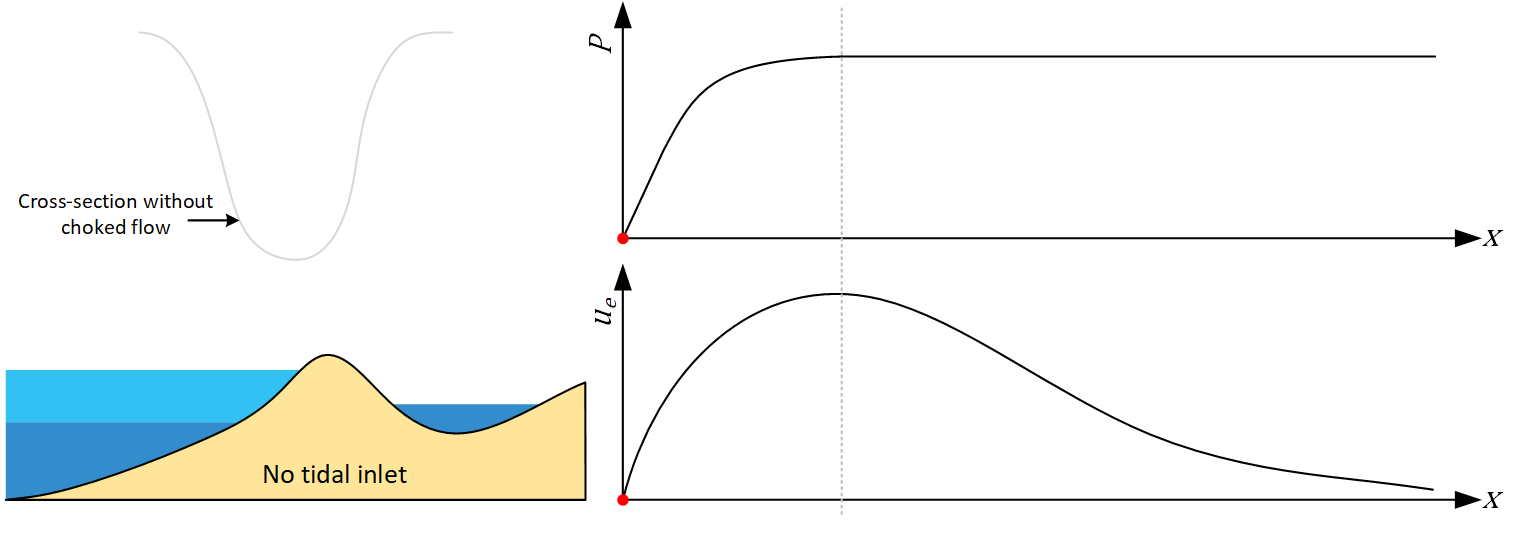

In [4]:
# Load the images
images = [Image.open(Path(f"../images/8_tidal_basins/8_Escoffier_interactive_{x}.png")) for x in range(1, 8)]

# Create the slider app
mod_8.image_app(images)

### Equilibrium velocity

The next step is to determine an equilibrium channel velocity $u_{eq}$ below which no erosion of the channel occurs. This velocity is only slightly dependent on the cross-section and can be approximated as just a function of sediment size. Larger sediment size leads to a larger $u_{eq}$ and vice versa (consider that larger particles have a higher threshold of motion). Escofier suggest that $u_{eq} = 0.9$ m/s is a good approximation. The closure curve and a value for $u_{eq}$ leads to the Escoffier curve as depicted in Figure 9.22 in the book, and also depicted below:

<img src="../images/8_tidal_basins/8_Ch9_Escoffier_type_1.png"
     style="display:block;float:none;margin-left:15%;margin-right:auto;width:60%">

Where the curve crosses $u_{eq}$ (Points B and D), the inlet reaches an equilibrium. What is the stability of the inlet at each of these points? Let's discuss in the next section.

### Inlet stability

How can the Escoffier curve be used to determine inlet stability? It is crucial to realise that if $u_e<u_{eq}$ (section A-B and section D-E), the velocity in the channel is too small to erode sediment and any sediment deposited in the inlet channel will remain there. Vice versa, if $u_e>u_{eq}$ (section B-D), the velocity in the channel is large enough to erode sediment and the cross-section will increase. As a consequence, a channel will attempt to reach point D, both if the initial channel dimensions place it on section B-D and if they place it on section D-E. This implies that point D is a naturally stable situation, for which the equilibirum relationship for the channel cross-section holds (Eq. 9.6 in the book). Point B represents an unstable equilibrium, since a channel is inclined to move away from point B, when a slight disturbance places it a bit to the left or to the right of point B. 

## Questions

Now that you know how an Escoffier curve is created and some of the physical processes behind it, it's time to test your understanding. Try to answer the questions below and give your answers in the corresponding code block.

### Question block 1: Channel stability

Consider the Escoffier curve below with points A, B, C, D and E. What happens to the channel cross-section ($X$) at locations 1, 2, 3, 4 and 5? Where does it move to, point A, B, C, D, E or neither (N)? Give your answers below and run the code block to validate your answers and view your feedback.

<img src="../images/8_tidal_basins/8_Ch9_Escoffier_stability_1.png"
     style="display:block;float:none;margin-left:15%;margin-right:auto;width:60%">

In [5]:
q = [
    "Q8a-cross_section_loc1",
    "Q8a-cross_section_loc2",
    "Q8a-cross_section_loc3",
    "Q8a-cross_section_loc4",
    "Q8a-cross_section_loc5",
]

question_industry.serve(q)

Column(width_policy='max')
    [0] Column(width_policy='max')
        [0] StaticText(name='Q-1', sizing_mode='stretch_width', value='What happens to the chann...)
        [1] RadioBoxGroup(name='Options', options=['A', 'B', 'C', ...])
        [2] Button(name='Submit', width=75)
        [3] StaticText(sizing_mode='stretch_width')
        [4] Markdown(None)
    [1] Column(width_policy='max')
        [0] StaticText(name='Q-2', sizing_mode='stretch_width', value='What happens to the chann...)
        [1] RadioBoxGroup(name='Options', options=['A', 'B', 'C', ...])
        [2] Button(name='Submit', width=75)
        [3] StaticText(sizing_mode='stretch_width')
        [4] Markdown(None)
    [2] Column(width_policy='max')
        [0] StaticText(name='Q-3', sizing_mode='stretch_width', value='What happens to the chann...)
        [1] RadioBoxGroup(name='Options', options=['A', 'B', 'C', ...])
        [2] Button(name='Submit', width=75)
        [3] StaticText(sizing_mode='stretch_width')
        [4] Markdown(None)
    [3] Column(width_policy='max')
        [0] StaticText(name='Q-4', sizing_mode='stretch_width', value='What happens to the chann...)
        [1] RadioBoxGroup(name='Options', options=['A', 'B', 'C', ...])
        [2] Button(name='Submit', width=75)
        [3] StaticText(sizing_mode='stretch_width')
        [4] Markdown(None)
    [4] Column(width_policy='max')
        [0] StaticText(name='Q-5', sizing_mode='stretch_width', value='What happens to the chann...)
        [1] RadioBoxGroup(name='Options', options=['A', 'B', 'C', ...])
        [2] Button(name='Submit', width=75)
        [3] StaticText(sizing_mode='stretch_width')
        [4] Markdown(None)

### Question block 2: Escoffier curve "types"

Below three Escoffier curves are shown. So far we have only considered the scenario where Point C lies above $u_{eq}$ (scenario S-I). However, two other scenarios can also exist: S-II where point C coincides with $u_{eq}$ and S-III where point C is below $u_{eq}$. Similar to the previous question, what happens now at locations 1, 2, and 3 for scenarios S-II and S-III? Try to answer the questions below.

#### Scenario S-I:
<img src="../images/8_tidal_basins/8_Ch9_Escoffier_type_1.png"
     style="display:block;float:none;margin-left:15%;margin-right:auto;width:60%">  

#### Scenario S-II:
<img src="../images/8_tidal_basins/8_Ch9_Escoffier_type_3.png"
     style="display:block;float:none;margin-left:15%;margin-right:auto;width:60%">

#### Scenario S-III:
<img src="../images/8_tidal_basins/8_Ch9_Escoffier_type_2.png"
     style="display:block;float:none;margin-left:15%;margin-right:auto;width:60%">

In [6]:
q = [
    "Q8a-cross_section_II_loc1",
    "Q8a-cross_section_II_loc2",
    "Q8a-cross_section_II_loc3",
    "Q8a-cross_section_III_loc1",
    "Q8a-cross_section_III_loc2",
    "Q8a-cross_section_III_loc3",
]

question_industry.serve(q)

Column(width_policy='max')
    [0] Column(width_policy='max')
        [0] StaticText(name='Q-6', sizing_mode='stretch_width', value='What happens to the chann...)
        [1] RadioBoxGroup(name='Options', options=['A', 'C', 'E', 'N'])
        [2] Button(name='Submit', width=75)
        [3] StaticText(sizing_mode='stretch_width')
        [4] Markdown(None)
    [1] Column(width_policy='max')
        [0] StaticText(name='Q-7', sizing_mode='stretch_width', value='What happens to the chann...)
        [1] RadioBoxGroup(name='Options', options=['A', 'C', 'E', 'N'])
        [2] Button(name='Submit', width=75)
        [3] StaticText(sizing_mode='stretch_width')
        [4] Markdown(None)
    [2] Column(width_policy='max')
        [0] StaticText(name='Q-8', sizing_mode='stretch_width', value='What happens to the chann...)
        [1] RadioBoxGroup(name='Options', options=['A', 'C', 'E', 'N'])
        [2] Button(name='Submit', width=75)
        [3] StaticText(sizing_mode='stretch_width')
        [4] Markdown(None)
    [3] Column(width_policy='max')
        [0] StaticText(name='Q-9', sizing_mode='stretch_width', value='What happens to the chann...)
        [1] RadioBoxGroup(name='Options', options=['A', 'C', 'E', 'N'])
        [2] Button(name='Submit', width=75)
        [3] StaticText(sizing_mode='stretch_width')
        [4] Markdown(None)
    [4] Column(width_policy='max')
        [0] StaticText(name='Q-10', sizing_mode='stretch_width', value='What happens to the chann...)
        [1] RadioBoxGroup(name='Options', options=['A', 'C', 'E', 'N'])
        [2] Button(name='Submit', width=75)
        [3] StaticText(sizing_mode='stretch_width')
        [4] Markdown(None)
    [5] Column(width_policy='max')
        [0] StaticText(name='Q-11', sizing_mode='stretch_width', value='What happens to the chann...)
        [1] RadioBoxGroup(name='Options', options=['A', 'C', 'E', 'N'])
        [2] Button(name='Submit', width=75)
        [3] StaticText(sizing_mode='stretch_width')
        [4] Markdown(None)

### Question block 3: Changes to the Escoffier curve

So far we have considered a typical Escoffier curve and asked you some questions about what happens to the tidal inlet. You have mastered working with the Escoffier curve, but are you also able to answer the questions below about the practical applications?

In [7]:
q = [
    "Q8a-escoffier_engineering",
    "Q8a-closure_vary_in_time",
]

question_industry.serve(q)

Column(width_policy='max')
    [0] Column(width_policy='max')
        [0] StaticText(name='Q-12', sizing_mode='stretch_width', value='How can you m...)
        [1] CheckBoxGroup(name='Options', options=['By reclaiming land in th...])
        [2] Button(name='Submit', width=75)
        [3] StaticText(sizing_mode='stretch_width')
        [4] Markdown(None)
    [1] Column(width_policy='max')
        [0] StaticText(name='Q-13', sizing_mode='stretch_width', value='How can the c...)
        [1] RadioBoxGroup(name='Options', options=['Via seasonal changes in ...])
        [2] Button(name='Submit', width=75)
        [3] StaticText(sizing_mode='stretch_width')
        [4] Markdown(None)

### The end

You have reached the end of this notebook 8a: Escoffier Curve. You can continue to work on the other notebooks for this week.